# Individual Function Testing

In [1]:
from z3 import *
from query_test import QueryTest
from utils import *
from query_info import *

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


In [ ]:
# Beer DB Test case

# Simple WHERE Test
# q1 = "SELECT * FROM drinker, frequents WHERE name = drinker and times_a_week > 2 and bar = 'James Joyce Pub'"
# q2 = "SELECT * FROM drinker, frequents WHERE name = drinker and times_a_week > 3 and bar = 'Talk of the Town'"

# OR Test
# q1 = 'SELECT * FROM drinker, frequents f1, frequents f2 WHERE name = f1.drinker AND f1.drinker = f2.drinker AND f1.times_a_week <> f2.times_a_week'
# q2 = 'SELECT * FROM drinker, frequents f1, frequents f2 WHERE name = f2.drinker AND name = f1.drinker AND (f1.times_a_week < f2.times_a_week OR f1.times_a_week >= f2.times_a_week)'
# q2 = 'SELECT * FROM drinker, frequents f1, frequents f2 WHERE (name = f2.drinker AND name = f1.drinker AND f1.times_a_week < f2.times_a_week) OR (name <> f2.drinker AND name = f1.drinker AND f1.times_a_week > f2.times_a_week)'


# GROUP BY
# q1 = "SELECT name FROM drinker, frequents f1, frequents f2 WHERE name = f1.drinker AND f1.drinker = f2.drinker AND f1.times_a_week <> f2.times_a_week GROUP BY name, f1.times_a_week * 2 + 5"
# q2 = 'SELECT name FROM drinker, frequents f1, frequents f2 WHERE name = f2.drinker AND name = f1.drinker AND (f1.times_a_week < f2.times_a_week OR f1.times_a_week >= f2.times_a_week) GROUP BY name, 5 + 2 * f1.times_a_week'

# HAVING
# q1 = "SELECT name || '@hi', AVG(f1.times_a_week) FROM drinker, frequents f1, frequents f2 WHERE name = f1.drinker AND f1.drinker = f2.drinker AND f1.times_a_week <> f2.times_a_week GROUP BY name, f1.times_a_week * 2 + 5 HAVING COUNT(f1.times_a_week) > 2 OR AVG(f1.times_a_week) > 2"
# q2 = "SELECT AVG(f1.times_a_week), name || '@hello' FROM drinker, frequents f1, frequents f2 WHERE name = f2.drinker AND name = f1.drinker AND (f1.times_a_week < f2.times_a_week OR f1.times_a_week >= f2.times_a_week) GROUP BY name, 5 + 1 * f1.times_a_week HAVING AVG(f1.times_a_week) > 2"

# Nested
# q1 = 'select * from (select * from frequents where times_a_week > 1) as f, drinker where name = f.drinker'
# q2 = 'select * from (select * from frequents where times_a_week > 2) as f, drinker where name = f.drinker'

# Correlated
# q1 = 'select * from drinker where exists (select * from frequents where drinker = name and times_a_week > 1)'
# q2 = 'select * from drinker where exists (select * from frequents where drinker = name and times_a_week > 2)'

# projected attr in nested
# q1 = 'select * from (select drinker, times_a_week + 3 as times from frequents where exists (select * from bar where bar = name)) as f, drinker where name = drinker and times > 2'
# q2 = 'select * from (select drinker, times_a_week + 2 as times from frequents where exists (select * from bar)) as f, drinker where name = drinker and times > 2'


# running example
# q1 = "SELECT L.beer, S1.bar, COUNT(*) FROM Likes L, Frequents F, Serves S1, Serves S2 WHERE L.drinker = F.drinker AND F.bar = S1.bar AND L.beer = S1.beer AND S1.beer = S2.beer AND S1.price <= S2.price AND F.drinker = 'Amy' GROUP BY F.drinker, L.beer, S1.bar"
# q2 = "SELECT s2.beer, s2.bar, COUNT(*) FROM Likes L, Serves s1, Serves s2, Frequents F WHERE L.drinker = 'Amy' AND L.beer = s1.beer AND L.beer = s2.beer AND s1.price > s2.price AND F.bar = s2.bar AND L.drinker = F.drinker GROUP BY s2.beer, s2.bar"
q1 = "SELECT beer FROM Serves WHERE bar = 'James Joyce Pub'"
q2 = "SELECT beer FROM Serves WHERE bar = 'The Edge'"
q1_info = QueryInfo(q1)
q2_info = QueryInfo(q2)
m = MappingInfo(q1_info, q2_info)
t = QueryTest(q1_info, q2_info, m.z3_var_lookup, m.table_mapping, m.table_mapping_reverse)

In [3]:
m.table_mapping
m.table_mapping_reverse

[{'Serves_0': 't_0'}, {'Serves_0': 't_0'}]

In [4]:
# t.test_where_having_min_overall_fo()
t.test_where_fg()

self.z3_var["Serves_0"][0] == StringVal('James Joyce Pub')
Repair Site #0: ['Serves.bar == "The Edge"']
Fix #0: Serves.bar == "James Joyce Pub"


In [5]:
t.test_group_by()

In [ ]:
t.test_select()

([], [])

# Overall Function Test

In [1]:
from z3 import *
from bool_test import QueryTest
from bool_test import *
from utils import *
import sys
import os
import time

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


In [ ]:
file_paths = ['coverage-test/a-query.txt',
              'coverage-test/b-query.txt',
              'coverage-test/c-query.txt',
              'coverage-test/d-query-1.txt',
              'coverage-test/d-query-2.txt']

total_q_cnt = 0
total_time = 0
where_time = 0
where_q_cnt = 0

for file_path in file_paths:
    with open(file_path, 'r') as file:
        queries = file.readlines()

        i = 0
        t = 0
        q1 = None
        q2 = None
        for query in queries:
            i += 1
            if i == 1:
                q1 = query[:-2]
                continue
            # elif i < 4:
            #     continue
            q2 = query[:-2]
            # print(q1, q2)
            old_stdout = sys.stdout # backup current stdout
            sys.stdout = open(os.devnull, "w")

            start = time.time()
            res = examine_queries(q1, q2)
            res1 = f'{file_path}, query {i - 1}: {res}'
            end = time.time()
            total_time += round((end - start) * 1000)
            if res == 'WHERE/HAVING':
                where_q_cnt += 1
                where_time += round((end - start) * 1000)

            sys.stdout = old_stdout # reset old stdout
            print(res1)
        total_q_cnt += i
        total_time += t

print(f'Average time for fixing a query: {total_time / total_q_cnt} ms / query')
print(f'Average time for fixing a query: {where_time / where_q_cnt} ms / query')

In [6]:
print(f'Average time for fixing a query in general: {total_time / total_q_cnt} ms / query')
print(f'Average time for fixing a WHERE query: {where_time / where_q_cnt} ms / query')
print(where_q_cnt, total_q_cnt)

Average time for fixing a query in general: 252.03416149068323 ms / query
Average time for fixing a WHERE query: 340.21888412017165 ms / query
233 322


In [2]:
# running example
# q1 = "SELECT L.beer, S1.bar, COUNT(*) FROM Likes L, Frequents F, Serves S1, Serves S2 WHERE L.drinker = F.drinker AND F.bar = S1.bar AND L.beer = S1.beer AND S1.beer = S2.beer AND S1.price <= S2.price AND F.drinker = 'Amy' GROUP BY F.drinker, L.beer, S1.bar"
# q2 = "SELECT s2.beer, s2.bar, COUNT(*) FROM Likes L, Serves s1, Serves s2, Frequents F WHERE L.drinker = 'Amy' AND L.beer = s1.beer AND L.beer = s2.beer AND s1.price > s2.price AND F.bar = s2.bar AND L.drinker = F.drinker GROUP BY s2.beer, s2.bar"
# q1_info = QueryInfo(q1)
# q2_info = QueryInfo(q2)
# m = MappingInfo(q1_info, q2_info)
# t = QueryTest(q1_info, q2_info, m.z3_var_lookup, m.table_mapping, m.table_mapping_reverse)

q1 = "SELECT drinker FROM Likes GROUP BY drinker HAVING COUNT(*) >= 2"
# q2 = "SELECT Frequents.drinker FROM Frequents GROUP BY drinker HAVING COUNT(Frequents.bar) = 1 OR COUNT(Frequents.bar) = 0"
q2 = "select drinker, count(*) from Likes group by drinker having count(*) > 1"
examine_queries(q1, q2)

WHERE/HAVING clauses are equivalent!
GROUP BY clauses are equivalent.


'SELECT'

[85.71428571428571, 0.0] [0.0, 100.0] [14.285714285714285, 0.0]


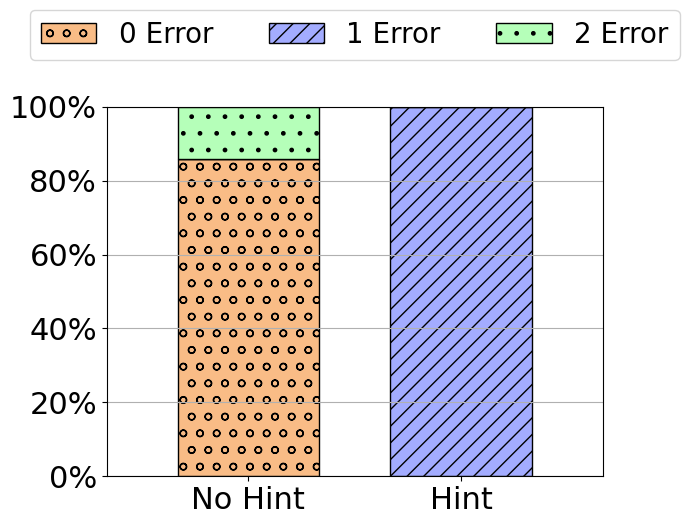

In [145]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick

cats = ['No Hint', 'Hint']
data = {'0':[6,0], '1':[0,7], '2':[1,0]}
df = pd.DataFrame(data, index=cats)

totals = [i+j+k for i,j,k in zip(df['0'], df['1'], df['2'])]
redBars = [i / j * 100 for i,j in zip(df['0'], totals)]
yellowBars = [i / j * 100 for i,j in zip(df['1'], totals)]
greenBars = [i / j * 100 for i,j in zip(df['2'], totals)]

print(redBars, yellowBars, greenBars)

barWidth = 1
names = ('No Hint','Hint')
r = [1,2.5]
# Create green Bars
plt.bar(r, redBars, color='#f9bc86', alpha=1, edgecolor='black', width=barWidth, label='0 Error', hatch='o')
# Create orange Bars
plt.bar(r, yellowBars, bottom=redBars, color='#a3acff', alpha=1, edgecolor='black', width=barWidth, label='1 Error', hatch='//')
# Create blue Bars
plt.bar(r, greenBars, bottom=[i+j for i,j in zip(redBars, yellowBars)], color='#b5ffb9', alpha=1, edgecolor='black', width=barWidth, label='2 Error', hatch='.')
 
# Custom x axis
plt.xticks(r, names, fontsize=22)
plt.yticks(fontsize=22)
plt.xlim([0,3.5])
# plt.xlabel("group")
plt.legend(loc='upper center',ncol=3, bbox_to_anchor=(0.5, 1.3), prop={'size':20})
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
# Show graphic
plt.grid(axis='y')
# plt.tight_layout()
plt.savefig('Q1-No-Hint-vs-Qr-Hint.png', bbox_inches='tight') 
plt.show()

[28.57142857142857, 12.5] [71.42857142857143, 62.5] [0.0, 25.0]


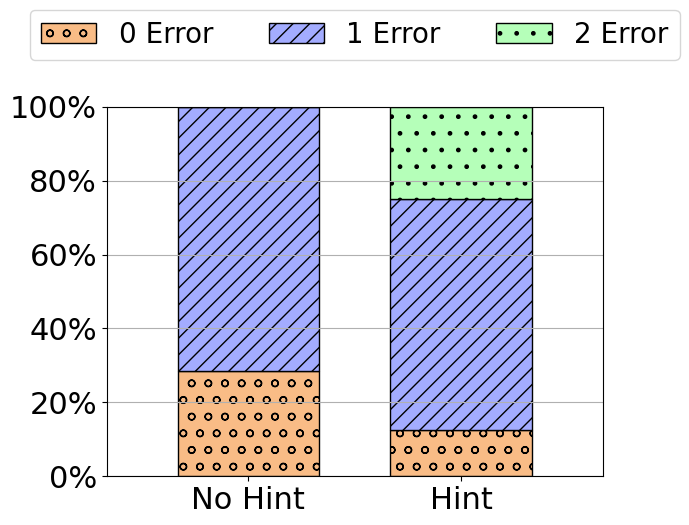

In [146]:
cats = ['No Hint', 'Hint']
data = {'0':[2,1], '1':[5,5], '2':[0,2]}
df = pd.DataFrame(data, index=cats)

totals = [i+j+k for i,j,k in zip(df['0'], df['1'], df['2'])]
redBars = [i / j * 100 for i,j in zip(df['0'], totals)]
yellowBars = [i / j * 100 for i,j in zip(df['1'], totals)]
greenBars = [i / j * 100 for i,j in zip(df['2'], totals)]

print(redBars, yellowBars, greenBars)

barWidth = 1
names = ('No Hint','Hint')
r = [1,2.5]
# Create green Bars
plt.bar(r, redBars, color='#f9bc86', alpha=1, edgecolor='black', width=barWidth, label='0 Error', hatch='o')
# Create orange Bars
plt.bar(r, yellowBars, bottom=redBars, color='#a3acff', alpha=1, edgecolor='black', width=barWidth, label='1 Error', hatch='//')
# Create blue Bars
plt.bar(r, greenBars, bottom=[i+j for i,j in zip(redBars, yellowBars)], color='#b5ffb9', alpha=1, edgecolor='black', width=barWidth, label='2 Error', hatch='.')
 
# Custom x axis
plt.xticks(r, names, fontsize=22)
plt.yticks(fontsize=22)
plt.xlim([0,3.5])
# plt.xlabel("group")
plt.legend(loc='upper center',ncol=3, bbox_to_anchor=(0.5, 1.3), prop={'size':20})
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
# Show graphic
plt.grid(axis='y')
# plt.tight_layout()
plt.savefig('Q2-No-Hint-vs-Qr-Hint.png', bbox_inches='tight')
plt.show()

[34.375, 37.5] [21.875, 50.0] [43.75, 12.5]


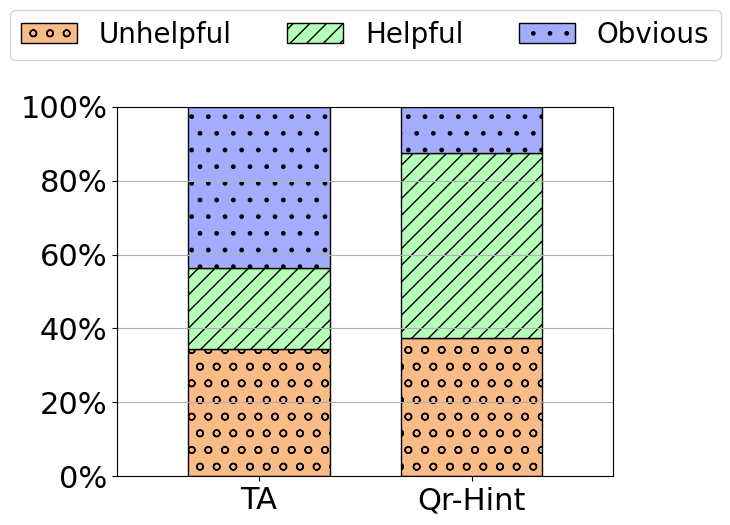

In [147]:
cats = ['TA', 'Qr-Hint']
data = {'0':[11,3], '1':[7,4], '2':[14,1]}
df = pd.DataFrame(data, index=cats)

totals = [i+j+k for i,j,k in zip(df['0'], df['1'], df['2'])]
redBars = [i / j * 100 for i,j in zip(df['0'], totals)]
yellowBars = [i / j * 100 for i,j in zip(df['1'], totals)]
greenBars = [i / j * 100 for i,j in zip(df['2'], totals)]

print(redBars, yellowBars, greenBars)

barWidth = 1
names = ('TA', 'Qr-Hint')
r = [1,2.5]
# Create green Bars
plt.bar(r, redBars, color='#f9bc86', alpha=1, edgecolor='black', width=barWidth, label='Unhelpful', hatch='o')
# Create orange Bars
plt.bar(r, yellowBars, bottom=redBars, color='#b5ffb9', alpha=1, edgecolor='black', width=barWidth, label='Helpful', hatch='//')
# Create blue Bars
plt.bar(r, greenBars, bottom=[i+j for i,j in zip(redBars, yellowBars)], color='#a3acff', alpha=1, edgecolor='black', width=barWidth, label='Obvious', hatch='.')
 
# Custom x axis
plt.xticks(r, names, fontsize=22)
plt.yticks(fontsize=22)
plt.xlim([0,3.5])
plt.ylim([0,100])
# plt.xlabel("group")
plt.legend(loc='upper center',ncol=3, bbox_to_anchor=(0.5, 1.3), prop={'size':20})
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
# Show graphic
plt.grid(axis='y')
# plt.tight_layout()
plt.savefig('Q3-Vote-Cast.png', bbox_inches='tight')
plt.show()

[35.714285714285715, 7.142857142857142] [17.857142857142858, 92.85714285714286] [46.42857142857143, 0.0]


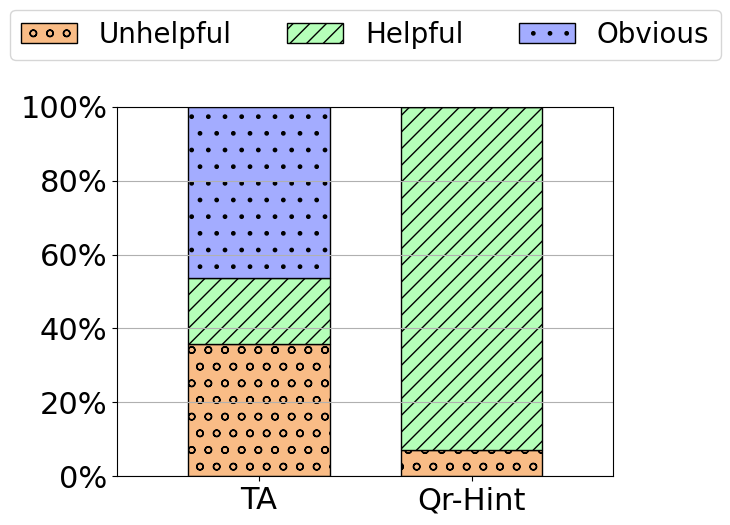

In [148]:
cats = ['TA', 'Qr-Hint']
data = {'0':[10,1], '1':[5,13], '2':[13,0]}
df = pd.DataFrame(data, index=cats)

totals = [i+j+k for i,j,k in zip(df['0'], df['1'], df['2'])]
redBars = [i / j * 100 for i,j in zip(df['0'], totals)]
yellowBars = [i / j * 100 for i,j in zip(df['1'], totals)]
greenBars = [i / j * 100 for i,j in zip(df['2'], totals)]

print(redBars, yellowBars, greenBars)

barWidth = 1
names = ('TA', 'Qr-Hint')
r = [1,2.5]
# Create green Bars
plt.bar(r, redBars, color='#f9bc86', alpha=1, edgecolor='black', width=barWidth, label='Unhelpful', hatch='o')
# Create orange Bars
plt.bar(r, yellowBars, bottom=redBars, color='#b5ffb9', alpha=1, edgecolor='black', width=barWidth, label='Helpful', hatch='//')
# Create blue Bars
plt.bar(r, greenBars, bottom=[i+j for i,j in zip(redBars, yellowBars)], color='#a3acff', alpha=1, edgecolor='black', width=barWidth, label='Obvious', hatch='.')
 
# Custom x axis
plt.xticks(r, names, fontsize=22)
plt.yticks(fontsize=22)
plt.xlim([0,3.5])
plt.ylim([0,100])
# plt.xlabel("group")
plt.legend(loc='upper center',ncol=3, bbox_to_anchor=(0.5, 1.3), prop={'size':20})
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
# Show graphic
plt.grid(axis='y')
# plt.tight_layout()
plt.savefig('Q4-Vote-Cast.png', bbox_inches='tight')
plt.show()

In [ ]:
# Matplotlib references
# https://python-graph-gallery.com/13-percent-stacked-barplot/
# https://matplotlib.org/stable/gallery/color/named_colors.html
# https://matplotlib.org/stable/gallery/shapes_and_collections/hatch_style_reference.html
